# Prompt chaining

This pattern breaks down large, complex tasks into smaller and more manageable problems. It's also known as Pipeline pattern and it's similar in nature to traditional orchestration: the output generated by one prompt is passed as input to the next promt in the chain.

> **🧭 When to use this pattern — and how Flyte helps**
>
> Reach for prompt chaining when a single prompt can't reliably do the whole job — the task breaks into distinct stages, needs tool calls between steps, or must carry state across multi-step reasoning. In Flyte each stage is its own `@env.task`: independently cached, retried, and inspectable, so a failure replays only the affected link rather than the entire chain.

## Implementation with Flyte v2

This notebook reimplements the two-step prompt chain using **Flyte v2 primitives only** — no LangChain, no LangGraph. Each prompt is a typed async task; tasks call tasks directly in pure Python, giving you durability, caching, and remote execution for free.

#### LangChain vs Flyte v2 — Key Differences

| Aspect | LangChain / LangGraph | Flyte v2 |
|--------|----------------------|----------|
| **Chain definition** | LCEL `\|` operator (`chain_a \| chain_b`) | Python functions — tasks call tasks directly |
| **State passing** | Untyped dict flowing through pipeline steps | Typed function arguments (serializable, inspectable) |
| **Checkpointing** | None — restart from scratch on failure | Each task result persists; resume from last completed step |
| **Observability** | Log parsing | Per-task traces in Flyte UI |
| **Caching** | Manual setup via cache stores | `cache="auto"` on `TaskEnvironment` |
| **Secrets** | `.env` / `os.environ` | `flyte.Secret` injected by cluster (no plaintext in code) |
| **Execution** | In-process only | Local or remote (containers on Kubernetes) |

### Prepare your environment

In [ ]:
!uv pip install flyte anthropic

Using Python 3.12.12 environment at: /Users/davidmirror/code/agentic-patterns-on-v2/.venv
Audited 2 packages in 54ms


### Start the devbox

If you haven't already, install the flyte package with the command above, then launch the local cluster:

In [ ]:
!flyte start devbox

Create a secret in Flyte for the API key (only done once):

In [ ]:

!flyte create secret ANTHROPIC_API_KEY --value sk-ant-...

- Flyte requires you to define a `TaskEnvironment`, an object that encapsulates the configuration your task will use during execution, including `Secrets`.
- Flyte allows you to [tune compute resources](https://www.union.ai/docs/v2/byoc/user-guide/task-configuration/resources/) (GPU, CPU, memory, ephemeral storage) via `Resources`.   
- [Caching](https://www.union.ai/docs/v2/byoc/user-guide/task-configuration/caching/) is enabled to save cost and drive down execution times for subsequent runs by avoiding LLM calls with the same inputs. 
- Flyte enables you to declare the desired configuration and contents of the [container image](https://www.union.ai/docs/v2/byoc/user-guide/task-configuration/container-images/) and have the image built automatically.

In [2]:
import flyte
from flyte import TaskEnvironment, Resources

env = TaskEnvironment(
    name="prompt_chaining_env",
    image=flyte.Image.from_debian_base().with_pip_packages("anthropic>=0.25.0"),
    resources=Resources(cpu="1", memory="1Gi"),
    cache="auto",
    secrets=[flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY")]
)


The two-prompt chain is implemented as two tasks where each task will run remotely on a container (or locally in a Python process) with its own compute resources.
We wrap each LLM call using [Flyte Traces](https://www.union.ai/docs/v2/union/user-guide/task-programming/traces/), enabling automatic resume from failures and capturing intermediate results.

This example uses the `anthropic` API and Python to:  

- Prompt 1: extract technical specs from `text_input`:


In [3]:


@flyte.trace
async def extract_specs(text_input: str) -> str:
    from anthropic import AsyncAnthropic
    client = AsyncAnthropic()
    response = await client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        messages=[{"role": "user", "content": f"Extract the technical specifications from:\n\n{text_input}"}],
    )
    return response.content[0].text


- Prompt 2: transform those specs into a JSON-like structure.

In [4]:
@flyte.trace
async def specs_to_json(specifications: str) -> str:
    from anthropic import AsyncAnthropic
    client = AsyncAnthropic()
    response = await client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        messages=[{"role": "user", "content": f"Transform into JSON with 'cpu', 'memory', 'storage':\n\n{specifications}"}],
    )
    return response.content[0].text


In Flyte V2 you can have tasks calling other tasks, giving you the flexibility to write orchestration logic in pure Python:

In [5]:
@env.task
async def process_description(text_input: str) -> str:
    specs = await extract_specs(text_input)
    return await specs_to_json(specs)

Finally, run the main task remotely:

In [ ]:
flyte.init_from_config()
run = flyte.run(process_description, text_input="Apple M4 Pro with 12 CPU cores, 16GB of memory, and 512GB of storage.")
run.wait()
print(run.outputs()[0])
print(run.url)



Output()

http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rvbtn5xwzxdhjf8g5bqm
```json
{
  "cpu": {
    "processor": "Apple M4 Pro",
    "cores": 12
  },
  "memory": {
    "ram": "16GB"
  },
  "storage": {
    "capacity": "512GB"
  }
}
```


This is how it looks in the Flyte Devbox UI the first time it's executed:

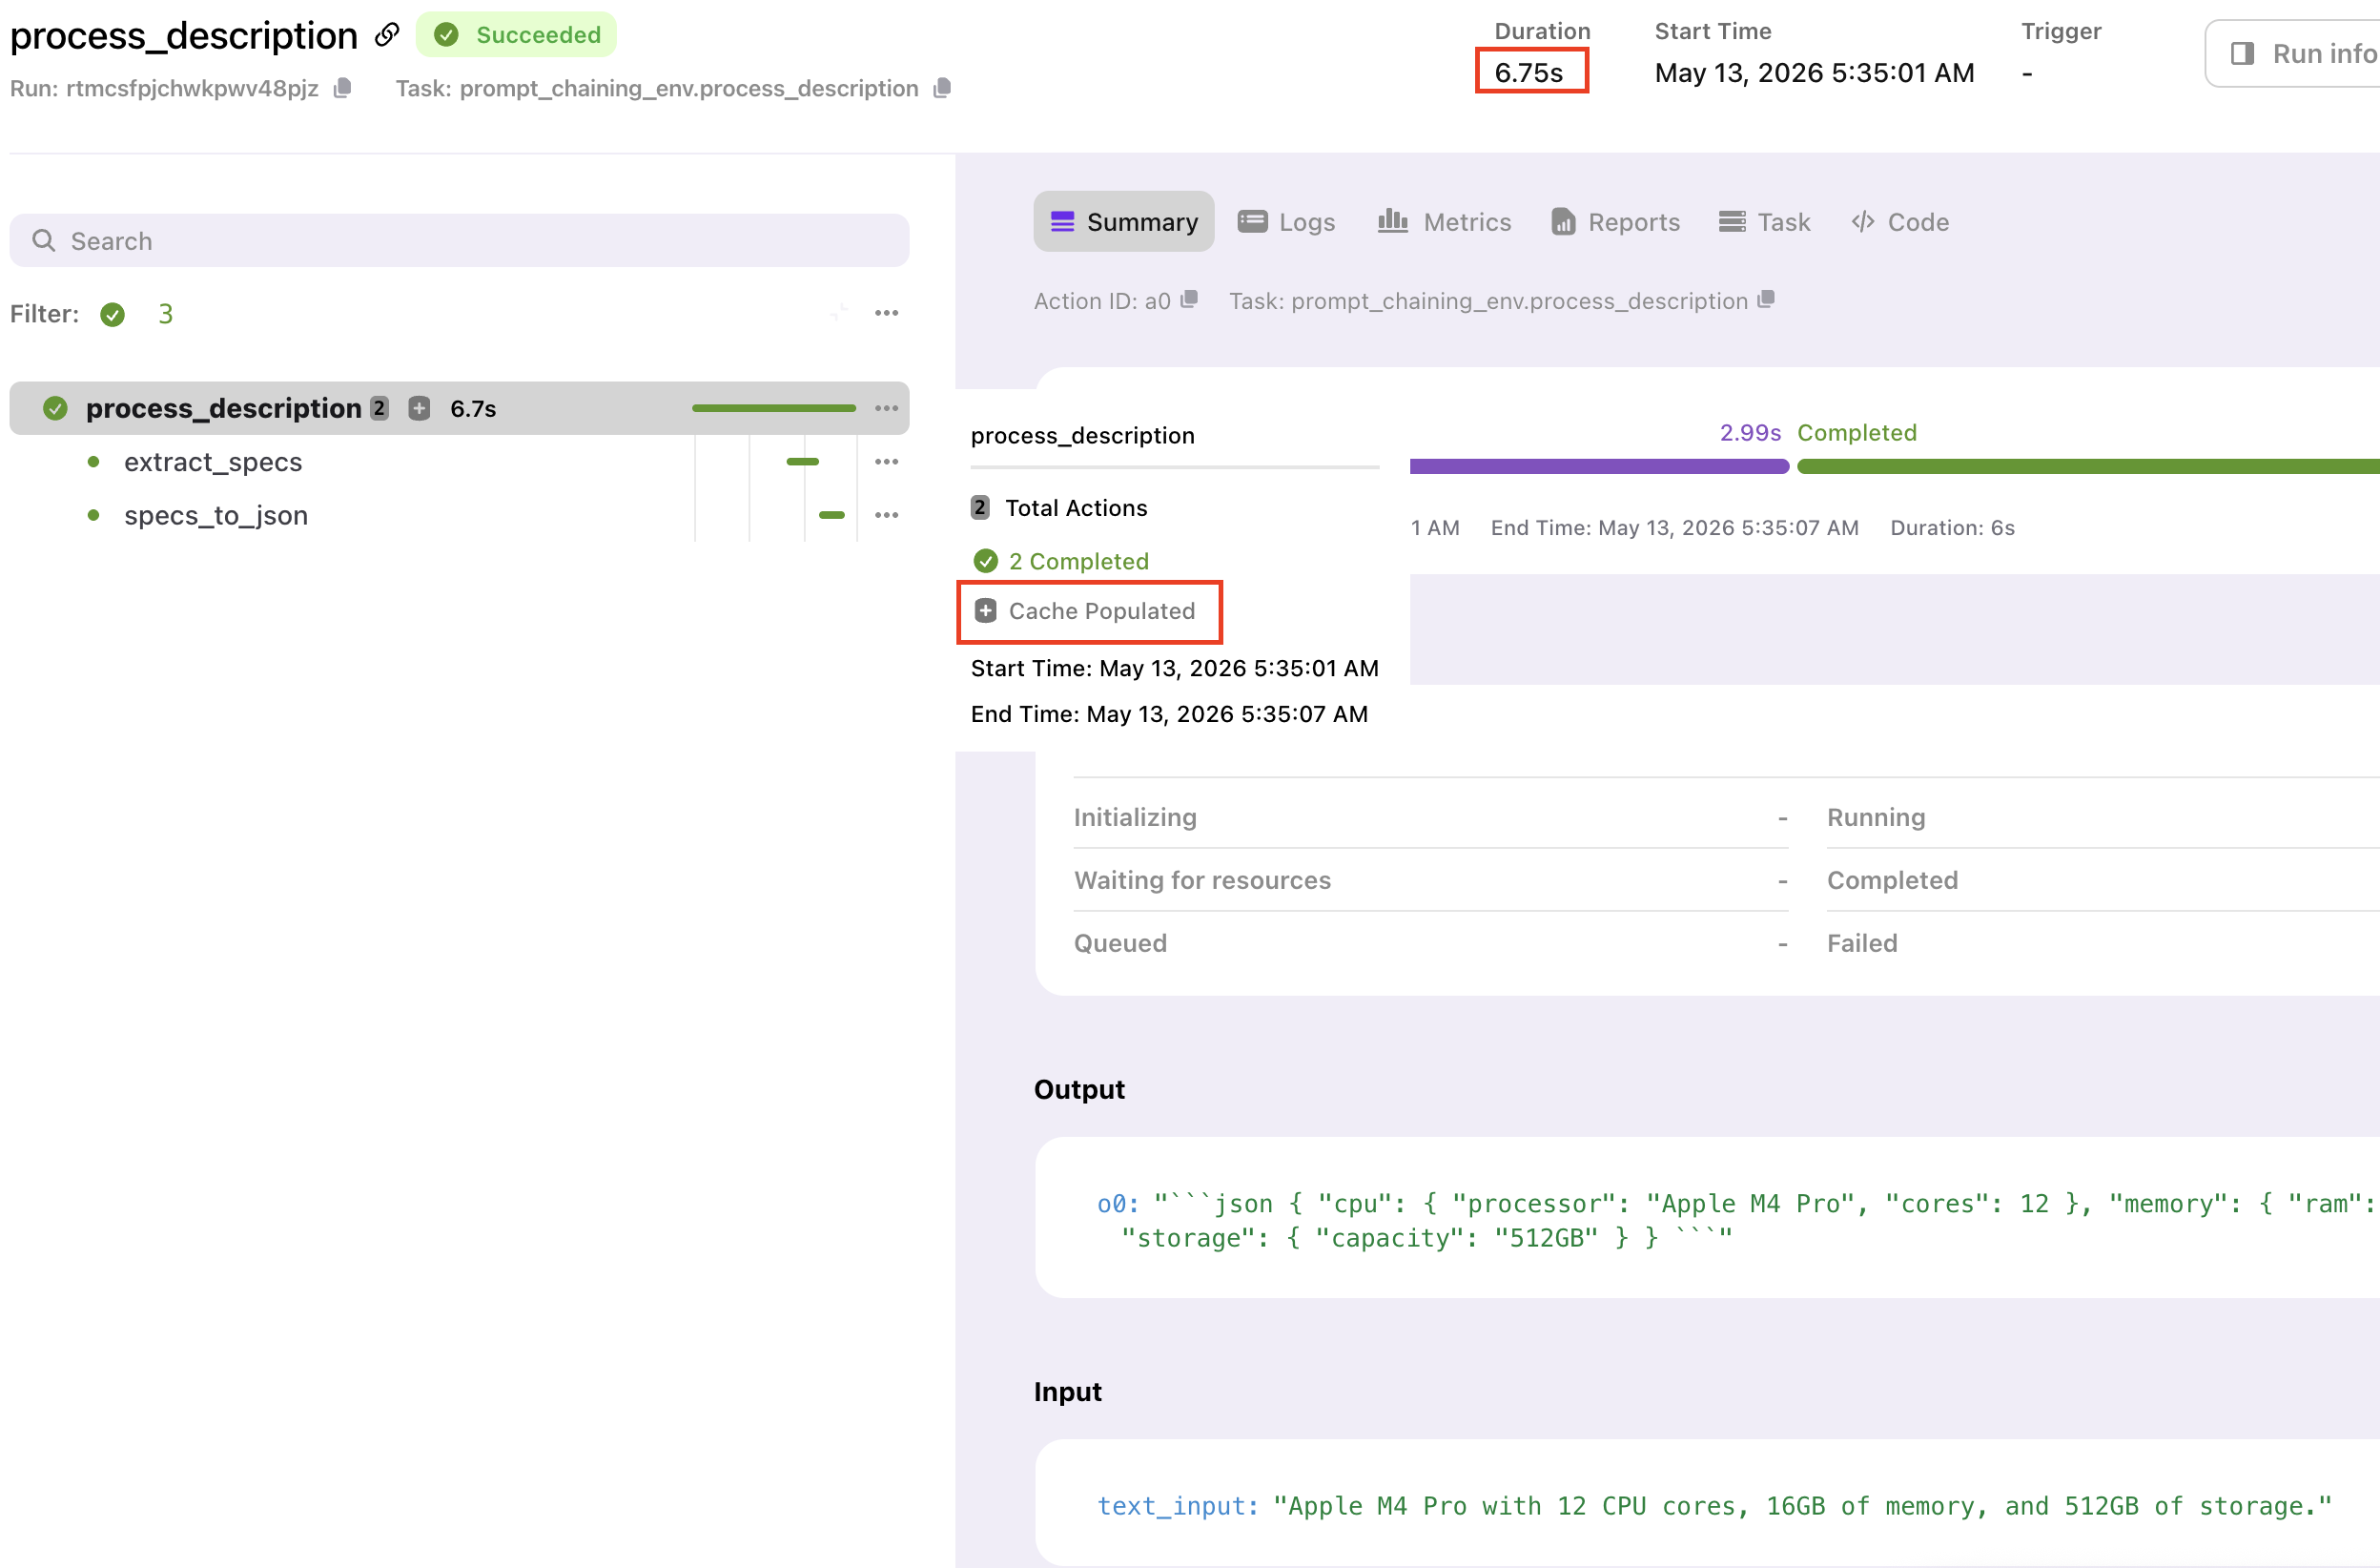

As the main task has `cache = auto` enabled, the outputs are stored with a hash of the inputs. This means the next time the agent finds the exact same input, it will only retrieve the outputs from blob storage. If you hit `Rerun` without changing the inputs, you can verify that the runtime dropped significantly saving you from unnecesary token and compute usage:

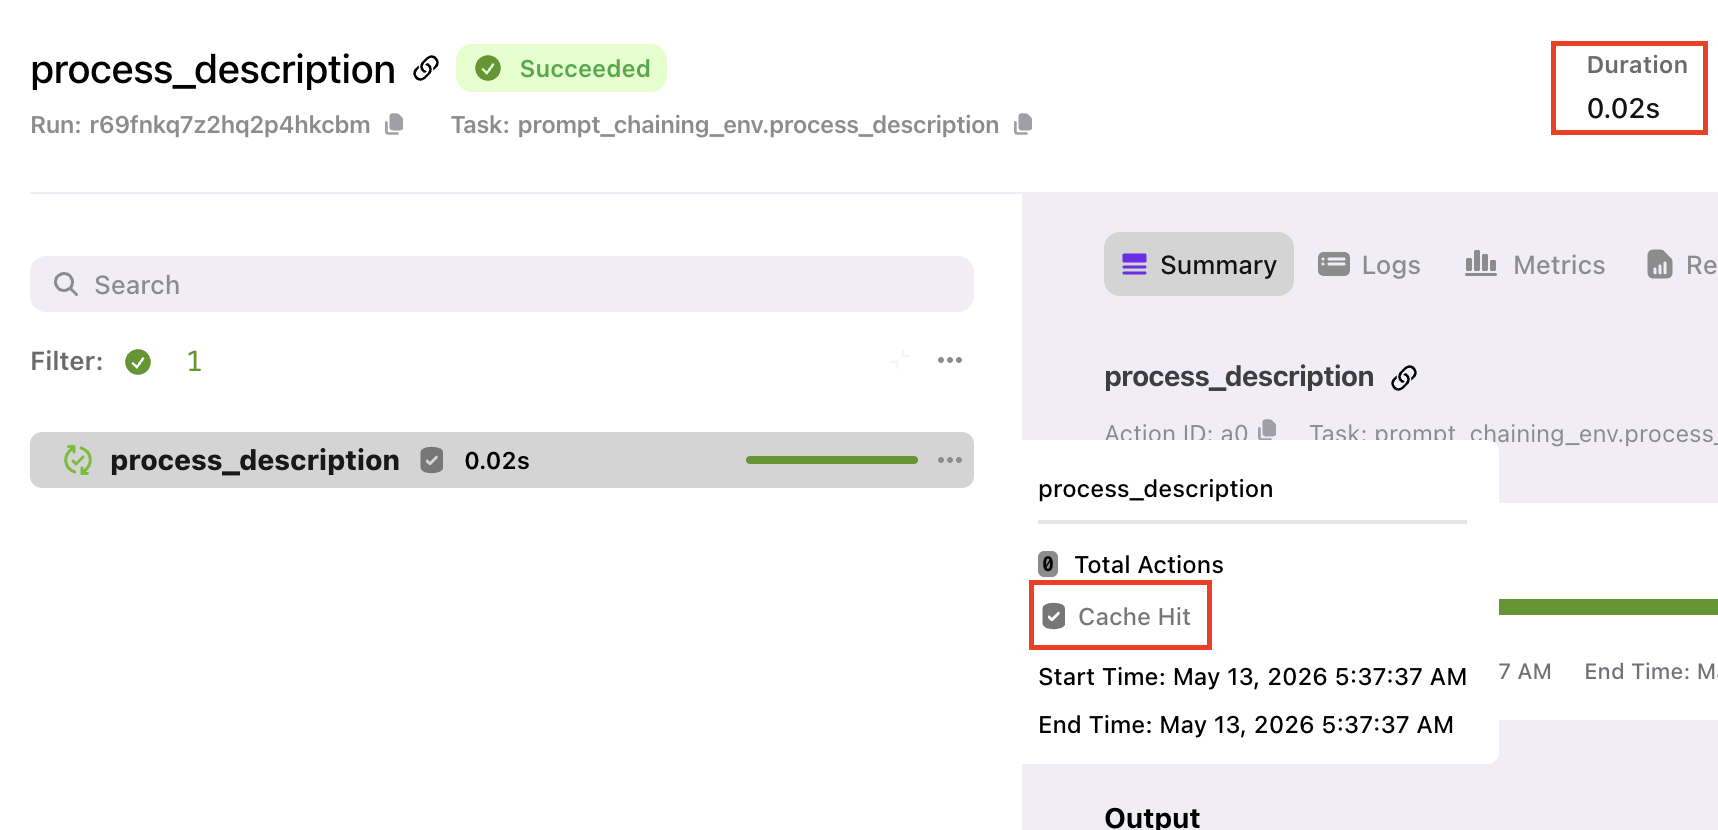



## Why not the Agent harness here?

A prompt chain is a **fixed, linear** sequence of LLM calls — step N's output is always step N+1's input. There is no tool to select and no branch to decide, so plain `@env.task` composition (`await step2(await step1(x))`) is the most idiomatic shape and keeps every stage independently cached and retriable. Reach for `flyte.ai.agents.Agent` only when the model itself must choose *which* action to take next (see the **tool-use**, **routing**, and **planning** notebooks).